# Results figures — data first, then the picture

Each section prints **the numbers that feed the plot**, per seed, before drawing it. If a
figure looks wrong, the table above it says whether the figure or the data is at fault.

Everything is editable in place. `STYLE` in cell 3 controls every figure at once; each figure
cell is self-contained below that, so you can rewrite one without touching the others.

`scripts/figures.py` is the batch version that writes the PDFs the thesis includes. When you
settle on a change here, port it there — otherwise the built figure and this notebook drift.


In [1]:
import pathlib, sys, glob, json, subprocess
import numpy as np
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
while not (ROOT / "ma").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%matplotlib inline
print("repo root:", ROOT)

repo root: /Users/brianezinwoke/Workspace/federated-active-causal-discovery-with-marl


In [2]:
# ---- every figure's appearance, in one place -------------------------------------------
STYLE = dict(
    learned   = "#0072B2",     # Okabe-Ito, colourblind safe
    myopic    = "#D55E00",
    random    = "#999999",
    third     = "#009E73",
    show_seeds   = True,       # draw individual seeds behind each mean
    seed_alpha   = 0.40,
    log_shd      = True,       # SHD spans 4 orders of magnitude; linear hides the top cells
    zero_floor   = 1e-5,       # where to draw a true 0.00000 on a log axis
    band         = (8, 12),    # shade the interval containing the crossover; None to disable
    figsize_tall = (5.0, 5.2),
    figsize_wide = (6.4, 3.0),
)
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["DejaVu Serif"], "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5, "figure.dpi": 130,
})
KS = [4, 8, 12, 20, 30]

## Loaders

Two sources, kept separate on purpose:

* `ckpt(k, which)` — `results/ckpt/k{NN}_{best,final}.json`, written by
  `scripts/global_shd_paired.py`. Paired episodes, so the uncertainty quoted is the standard
  error of the per-episode **difference**, not of either arm alone.
* `sweep(k)` — `results/sweep/oracle/*.json`, the training run's own evaluation pass. This is
  the **final** policy, which is why recovery rate and SHD must not be quoted from a single
  column without saying so.

In [3]:
def ckpt(k, which="best"):
    return json.loads((ROOT / f"results/ckpt/k{k:02d}_{which}.json").read_text())

def sweep(k):
    out = []
    for p in sorted(glob.glob(str(ROOT / f"results/sweep/oracle/k{k:02d}s50n04b150_s*.json"))):
        out.append(json.loads(pathlib.Path(p).read_text()))
    return out

def central(cell, arm):
    out = []
    for p in sorted(glob.glob(str(ROOT / f"results/central/v2_{cell}_{arm}_s*.json"))):
        out.append(json.loads(pathlib.Path(p).read_text()))
    return out

def table(rows, head, widths=None):
    """Aligned monospace table. Deliberately not pandas -- one less dependency to install."""
    widths = widths or [max(len(str(h)), 11) for h in head]
    line = "  ".join(str(h).rjust(w) for h, w in zip(head, widths))
    print(line); print("-" * len(line))
    for r in rows:
        print("  ".join((f"{v:.5f}" if isinstance(v, float) else str(v)).rjust(w)
                        for v, w in zip(r, widths)))

## 1. The crossover

The central claim: a myopic rule is *sufficient* at small windows and degrades as the window
grows, so the learned policy's advantage changes sign. Check both criteria agree on where.

In [4]:
rows = []
for k in KS:
    succ = [(r["arms"]["learned"]["success"], r["arms"]["greedy_uncertainty"]["success"])
            for r in sweep(k)]
    shd_l = [r["means"]["learned"]["hard"] for r in ckpt(k, "best")]
    shd_g = [r["means"]["greedy"]["hard"]  for r in ckpt(k, "best")]
    rows.append([k, np.mean([l for l, _ in succ]), np.mean([g for _, g in succ]),
                 np.mean([l - g for l, g in succ]), np.mean(shd_l), np.mean(shd_g),
                 np.mean(shd_l) / np.mean(shd_g) if np.mean(shd_g) else 0.0])
table(rows, ["k_v", "recov L", "recov M", "gap", "SHD L", "SHD M", "L/M"])
print("\nper-seed SHD, learned (selected checkpoint):")
for k in KS:
    print(f"  k={k:<3} " + "  ".join(f"{r['means']['learned']['hard']:.5f}" for r in ckpt(k)))

        k_v      recov L      recov M          gap        SHD L        SHD M          L/M
-----------------------------------------------------------------------------------------
          4      0.80833      0.88333     -0.07500      0.01024      0.00611      1.67532
          8      0.92167      0.94667     -0.02500      0.00113      0.00082      1.39130
         12      0.97667      0.91833      0.05833      0.00014      0.00077      0.18812
         20      0.98000      0.89667      0.08333      0.00000      0.00053      0.00000
         30      0.96833      0.84333      0.12500      0.00038      0.00042      0.90808

per-seed SHD, learned (selected checkpoint):
  k=4   0.01024  0.00738  0.01310
  k=8   0.00080  0.00027  0.00234
  k=12  0.00014  0.00007  0.00023
  k=20  0.00000  0.00000  0.00000
  k=30  0.00108  0.00000  0.00006


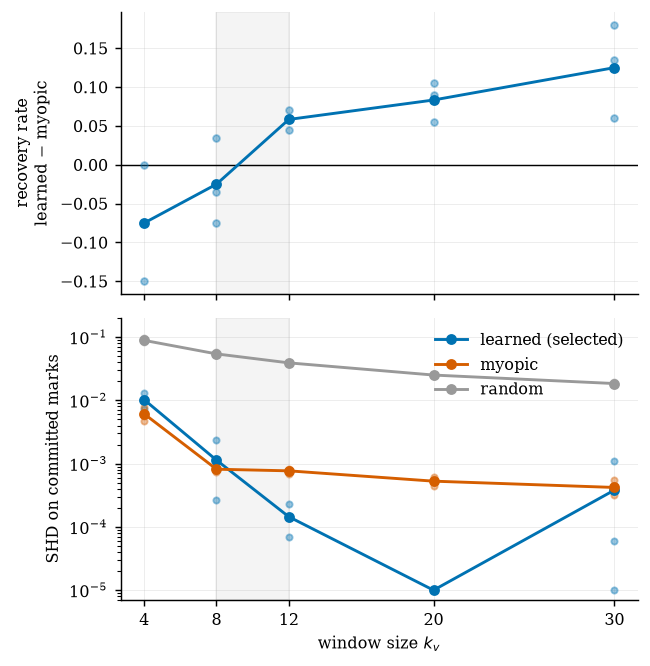

In [5]:
fig, (top, bot) = plt.subplots(2, 1, figsize=STYLE["figsize_tall"], sharex=True)

gaps = [[r["arms"]["learned"]["success"] - r["arms"]["greedy_uncertainty"]["success"]
         for r in sweep(k)] for k in KS]
top.axhline(0, color="black", lw=0.8)
if STYLE["show_seeds"]:
    for x, g in zip(KS, gaps):
        top.scatter([x]*len(g), g, s=14, color=STYLE["learned"], alpha=STYLE["seed_alpha"], zorder=3)
top.plot(KS, [np.mean(g) for g in gaps], "o-", color=STYLE["learned"], lw=1.6, ms=5, zorder=4)
top.set_ylabel("recovery rate\nlearned $-$ myopic")

floor = STYLE["zero_floor"]
for label, arm, colour in (("learned (selected)", "learned", STYLE["learned"]),
                           ("myopic", "greedy", STYLE["myopic"]),
                           ("random", "random_vary", STYLE["random"])):
    seeds = [[r["means"][arm]["hard"] for r in ckpt(k)] for k in KS]
    if STYLE["show_seeds"]:
        for x, v in zip(KS, seeds):
            bot.scatter([x]*len(v), [max(q, floor) for q in v], s=12, color=colour,
                        alpha=STYLE["seed_alpha"], zorder=3)
    bot.plot(KS, [max(np.mean(v), floor) for v in seeds], "o-", color=colour,
             lw=1.6, ms=5, label=label, zorder=4)
if STYLE["log_shd"]:
    bot.set_yscale("log"); bot.set_ylim(floor*0.7, 2e-1)
bot.set_xlabel("window size $k_v$"); bot.set_ylabel("SHD on committed marks")
bot.legend(loc="upper right", frameon=False)
for ax in (top, bot):
    ax.set_xticks(KS)
    if STYLE["band"]:
        ax.axvspan(*STYLE["band"], color="black", alpha=0.045, zorder=0)
fig.tight_layout(); plt.show()

## 2. Which checkpoint

The training run evaluates the **final** policy; the thesis reports the **early-stopped** one,
selected on a training statistic. Below the crossover the choice is inert. Above it, it is
worth a factor of 2.3 at $k_v=20$ and 16 at $k_v=30$ — so the table has to show both.

In [6]:
rows = []
for k in KS:
    b = [r["means"]["learned"]["hard"] for r in ckpt(k, "best")]
    f = [r["means"]["learned"]["hard"] for r in ckpt(k, "final")]
    g = [r["means"]["greedy"]["hard"]  for r in ckpt(k, "best")]
    rows.append([k, np.mean(b), np.mean(f), np.mean(g),
                 (np.mean(f)/np.mean(b)) if np.mean(b) else float("inf")])
table(rows, ["k_v", "selected", "final", "myopic", "final/sel"])
print("\nresolved fraction -- if these differ, an arm is winning by committing to less:")
for k in KS:
    print(f"  k={k:<3} " + "  ".join(f"{a}={np.mean([r['means'][a]['resolved'] for r in ckpt(k)]):.3f}"
                                     for a in ("learned", "greedy", "random_vary")))

        k_v     selected        final       myopic    final/sel
---------------------------------------------------------------
          4      0.01024      0.00865      0.00611      0.84496
          8      0.00113      0.00082      0.00082      0.71875
         12      0.00014      0.00014      0.00077      1.00000
         20      0.00000      0.00124      0.00053          inf
         30      0.00038      0.00677      0.00042     17.75767

resolved fraction -- if these differ, an arm is winning by committing to less:
  k=4   learned=0.960  greedy=0.965  random_vary=0.882
  k=8   learned=0.970  greedy=0.971  random_vary=0.917
  k=12  learned=0.972  greedy=0.971  random_vary=0.933
  k=20  learned=0.973  greedy=0.973  random_vary=0.948
  k=30  learned=0.975  greedy=0.975  random_vary=0.957


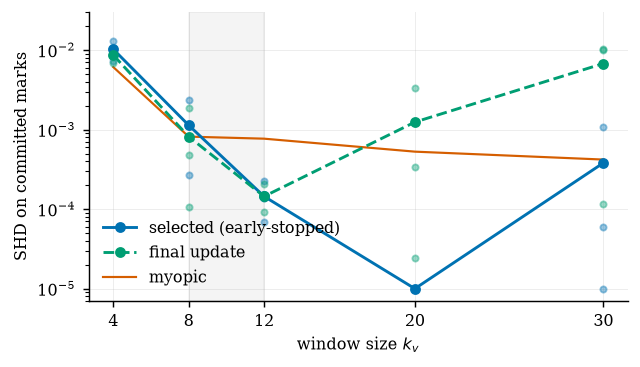

In [7]:
fig, ax = plt.subplots(figsize=(5.0, 2.9))
floor = STYLE["zero_floor"]
for which, label, colour, ls in (("best", "selected (early-stopped)", STYLE["learned"], "-"),
                                 ("final", "final update", STYLE["third"], "--")):
    seeds = [[r["means"]["learned"]["hard"] for r in ckpt(k, which)] for k in KS]
    if STYLE["show_seeds"]:
        for x, v in zip(KS, seeds):
            ax.scatter([x]*len(v), [max(q, floor) for q in v], s=12, color=colour,
                       alpha=STYLE["seed_alpha"], zorder=3)
    ax.plot(KS, [max(np.mean(v), floor) for v in seeds], "o"+ls, color=colour,
            lw=1.6, ms=5, label=label, zorder=4)
ax.plot(KS, [np.mean([r["means"]["greedy"]["hard"] for r in ckpt(k)]) for k in KS],
        "-", color=STYLE["myopic"], lw=1.2, label="myopic", zorder=2)
if STYLE["log_shd"]: ax.set_yscale("log"); ax.set_ylim(floor*0.7, 3e-2)
ax.set_xticks(KS)
if STYLE["band"]: ax.axvspan(*STYLE["band"], color="black", alpha=0.045, zorder=0)
ax.set_xlabel("window size $k_v$"); ax.set_ylabel("SHD on committed marks")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout(); plt.show()

## 3. Where the error lands

Split the same distance by pair class. A pair with an endpoint in the acting agent's private
block is scored; a shared–shared pair is required of nobody in particular. Source:
`docs/RESULTS_LEDGER_2026_09_01.md` §1.3 (60 episodes, four runs) — **re-derive from
`scripts/shd_by_pair_class.py` before this goes in the thesis.**

        arm       scored     unscored
-------------------------------------
    learned      0.00011      0.00036
     myopic      0.00061      0.00000
     random      0.02459      0.00347


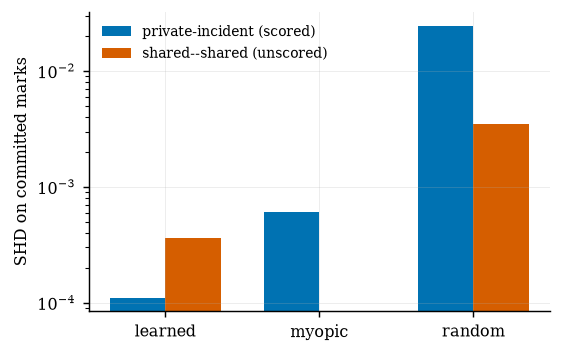

In [8]:
PAIR_CLASS = {           # arm: (private-incident, shared-shared)
    "learned": (0.00011, 0.00036),
    "myopic":  (0.00061, 0.00000),
    "random":  (0.02459, 0.00347),
}
table([[k, *v] for k, v in PAIR_CLASS.items()], ["arm", "scored", "unscored"])

fig, ax = plt.subplots(figsize=(4.4, 2.8))
x = np.arange(len(PAIR_CLASS)); w = 0.36
ax.bar(x - w/2, [v[0] for v in PAIR_CLASS.values()], w, label="private-incident (scored)",
       color=STYLE["learned"])
ax.bar(x + w/2, [v[1] for v in PAIR_CLASS.values()], w, label="shared--shared (unscored)",
       color=STYLE["myopic"])
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(PAIR_CLASS.keys())
ax.set_ylabel("SHD on committed marks"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

## 4. Attribution obeys a closed form

`scripts/attr_model.py` is run live rather than transcribed. The one-peer cell is excluded by
the model's own construction and should sit **off** the line — if it ever sits on it, the
model is fitting something it should not.

In [9]:
proc = subprocess.run([sys.executable, str(ROOT / "scripts/attr_model.py")],
                      capture_output=True, text=True, cwd=ROOT)
print(proc.stdout)
rows = [(p[0], int(p[1]), float(p[4]), float(p[5]))
        for p in (l.split() for l in proc.stdout.splitlines())
        if len(p) == 7 and p[0].startswith("k") and p[1].isdigit()]

          cell partners P(res|1pair) share 1pair predicted measured residual
----------------------------------------------------------------------------
     k12s50n02        1        1.000       0.225     0.225    0.488   +0.263
     k12s50n03        2        0.798       0.389     0.310    0.284   -0.026
     k12s50n04        3        0.765       0.477     0.365    0.330   -0.034
     k12s50n08        7        0.047       0.639     0.030    0.028   -0.002
     k12s25n04        3        0.941       0.845     0.795    0.755   -0.041
     k12s75n04        3        0.782       0.335     0.262    0.267   +0.005
     k20s50n04        3        0.667       0.321     0.214    0.196   -0.018

largest absolute residual: 0.263
Groups explaining two or more pairs are assumed to contribute ZERO, which holds at
every partner count above one. At ONE partner they do contribute and the model
under-predicts by design -- that cell is the exception that identifies the cause.



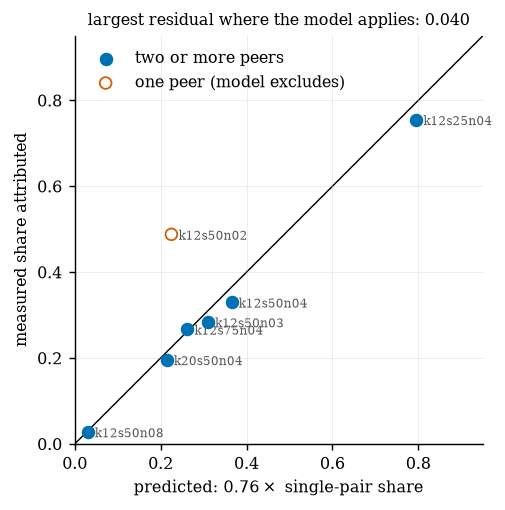

In [10]:
fig, ax = plt.subplots(figsize=(4.3, 4.0))
lim = 0.95
ax.plot([0, lim], [0, lim], color="black", lw=0.8, zorder=1)
ok  = [r for r in rows if r[1] > 1]
exc = [r for r in rows if r[1] <= 1]
ax.scatter([r[2] for r in ok], [r[3] for r in ok], s=42, color=STYLE["learned"],
           zorder=4, label="two or more peers")
ax.scatter([r[2] for r in exc], [r[3] for r in exc], s=42, facecolors="none",
           edgecolors=STYLE["myopic"], zorder=4, label="one peer (model excludes)")
for cell, peers, pred, meas in rows:
    ax.annotate(cell, (pred, meas), fontsize=6.5, xytext=(4, -3),
                textcoords="offset points", color="#555555")
resid = max(abs(m - p) for _, peers, p, m in rows if peers > 1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
ax.set_xlabel(r"predicted: $0.76\times$ single-pair share")
ax.set_ylabel("measured share attributed")
ax.set_title(f"largest residual where the model applies: {resid:.3f}", fontsize=9)
ax.legend(loc="upper left", frameon=False); fig.tight_layout(); plt.show()

## 5. The price of decentralisation

`A` is the federated baseline; `E` removes the information partition (partners' beliefs and
counts visible) **and** the optimiser partition (trajectories pooled rather than FedAvg).
Action rights stay partitioned in both, so this is the cost of partitioning *information,
reward and optimisation*, not of decentralisation entire.

Recovery rate saturates here, so read the SHD table underneath it — that is where the two
arms actually differ.

In [11]:
for cell in ("k12", "k20"):
    print(f"--- {cell}   joint recovery rate")
    rows = []
    for arm in ("A", "E"):
        runs = central(cell, arm)
        if not runs: continue
        get = lambda key: [r["arms"][key]["success"] for r in runs if r["arms"].get(key)]
        rows.append([arm, np.mean(get("learned")), np.mean(get("greedy_uncertainty")),
                     np.mean(get("greedy_partitioned")), np.mean(get("random_vary"))])
    table(rows, ["arm", "learned", "myopic", "partitioned", "random"])
    print()

print("--- SHD on committed marks, per seed (results/central/shd_k20_*.json)")
for arm in ("A", "E"):
    p = ROOT / f"results/central/shd_k20_{arm}.json"
    if not p.exists(): continue
    d = json.loads(p.read_text())
    print(f"  {arm}: " + "  ".join(f"{e['means']['learned']['hard']:.5f}" for e in d)
          + f"   mean {np.mean([e['means']['learned']['hard'] for e in d]):.5f}")

--- k12   joint recovery rate


        arm      learned       myopic  partitioned       random
---------------------------------------------------------------
          A      0.97083      0.92667      0.74500      0.02500
          E      0.96250      0.92667      0.74500      0.02500

--- k20   joint recovery rate
        arm      learned       myopic  partitioned       random
---------------------------------------------------------------
          A      0.99833      0.89667      0.48667      0.00667
          E      1.00000      0.89667      0.48667      0.00667

--- SHD on committed marks, per seed (results/central/shd_k20_*.json)
  A: 0.00066  0.00000  0.00000   mean 0.00022
  E: 0.00000  0.00000  0.00000   mean 0.00000


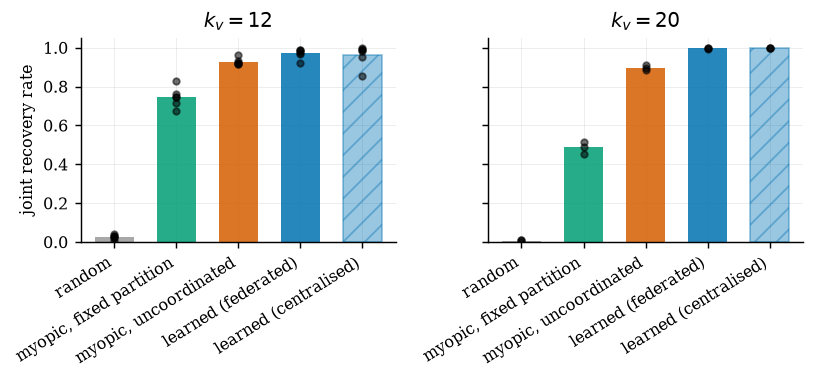

In [12]:
series = [("random", "random_vary", STYLE["random"]),
          ("myopic, fixed partition", "greedy_partitioned", STYLE["third"]),
          ("myopic, uncoordinated", "greedy_uncertainty", STYLE["myopic"]),
          ("learned (federated)", "learned", STYLE["learned"])]
fig, axes = plt.subplots(1, 2, figsize=STYLE["figsize_wide"], sharey=True)
for ax, cell in zip(axes, ("k12", "k20")):
    for i, (label, key, colour) in enumerate(series):
        vals = [r["arms"][key]["success"] for r in central(cell, "A") if r["arms"].get(key)]
        if not vals: continue
        ax.bar(i, np.mean(vals), 0.62, color=colour, alpha=0.85, zorder=2)
        if STYLE["show_seeds"]:
            ax.scatter([i]*len(vals), vals, s=13, color="black", alpha=0.55, zorder=4)
    cen = [r["arms"]["learned"]["success"] for r in central(cell, "E")]
    if cen:
        ax.bar(len(series), np.mean(cen), 0.62, color=STYLE["learned"], alpha=0.4,
               hatch="//", edgecolor=STYLE["learned"], zorder=2)
        if STYLE["show_seeds"]:
            ax.scatter([len(series)]*len(cen), cen, s=13, color="black", alpha=0.55, zorder=4)
    ax.set_xticks(range(len(series)+1))
    ax.set_xticklabels([s[0] for s in series] + ["learned (centralised)"], rotation=32, ha="right")
    ax.set_title(f"$k_v={cell[1:]}$"); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("joint recovery rate")
fig.tight_layout(); plt.show()